In [1]:
import math
import pickle
from functools import lru_cache

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from matplotlib.lines import Line2D

import imprl.agents
import imprl.envs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.style.use("default")
plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman"]})

In [2]:
ENV_NAME = "k_out_of_n_infinite"
RANDOM_SEEDS = 10

SETTINGS = [f"hard-{k}-of-4_infinite" for k in range(1, 5)]
SETTING_NAMES = [f"{k}-out-of-4" for k in range(1, 5)]

ALGORITHMS = [
    "DDQN",
    "JAC",
    "DCMAC",
    "IACC_PS",
    "MAPPO_PS",
    "QMIX_PS",
    "VDN_PS",
    "IAC_PS",
    "IPPO_PS",
]
ALGORITHM_NAMES = [
    "DDQN",
    "JAC",
    "DCMAC",
    "IACC-PS",
    "MAPPO-PS",
    "QMIX-PS",
    "VDN-PS",
    "IAC-PS",
    "IPPO-PS",
]

# Belief Space Plots

A belief over 3 states is a vector $b = (r_0,r_1,r_2)$ with $r_i \ge 0$ and $r_0+r_1+r_2=1$.

### Simplex view
For 3 states, the set of all valid beliefs forms a 2D simplex, which we visualize as an equilateral triangle.

- Each vertex corresponds to a pure belief:
  - Vertex **A**: $b=(1,0,0)$
  - Vertex **B**: $b=(0,1,0)$
  - Vertex **C**: $b=(0,0,1)$

- Any belief $b$ lies inside the triangle and can be interpreted as a convex combination of the vertices.

### Mapping from belief to 2D point
We place the triangle in 2D with vertices
- $v_0=(0,0)$, $v_1=(1,0)$, $v_2=\left(\tfrac{1}{2}, \tfrac{\sqrt{3}}{2}\right)$

and map $b=(r_0,r_1,r_2)$ to the point
- $(x,y)=r_0 v_0 + r_1 v_1 + r_2 v_2$
- $x = r_1 + \tfrac{1}{2}r_2$, $y = \tfrac{\sqrt{3}}{2}\,r_2$

<img src="./barycentric_coordinates.png" width=20%>

### How to read the plot
- The numeric labels near **A, B, C** are the belief weights $(r_0,r_1,r_2)$.
- The plotted point **P** is the belief location given by the weighted average above.
- Moving toward a vertex increases the corresponding probability:
  - larger $r_0$ moves **P** toward **A**
  - larger $r_1$ moves **P** toward **B**
  - larger $r_2$ moves **P** toward **C**
- If one weight is zero, the point lies on the opposite edge.

In [3]:
CARTESIAN = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, math.sqrt(3) / 2]])

In [4]:
@lru_cache(maxsize=None)
def _load_rollout_data_dict(setting, alg):

    rollout_data_path = (
        f"./data/rollout_data/{ENV_NAME}/{setting}/{alg}/rollout_data.pkl"
    )
    with open(rollout_data_path, "rb") as f:
        return pickle.load(f)


def load_rollout_data(setting, alg, keys):

    rollout_data = _load_rollout_data_dict(setting, alg)

    # Fast path for a single key.
    if isinstance(keys, str):
        return np.stack([data[keys] for data in rollout_data.values()], axis=0)

    # Multi-key path: collect all requested arrays in one pass.
    keys = tuple(keys)
    buckets = {key: [] for key in keys}
    for data in rollout_data.values():
        for key in keys:
            buckets[key].append(data[key])

    return tuple(np.stack(buckets[key], axis=0) for key in keys)


In [5]:
def plot_belief_space_with_actions(env_setting, save_fig=False, num_trajectories=100):

    n_components = 4
    time_limit = 20

    ALL_ALGORITHMS = ["SARSOP"] + ALGORITHMS
    ALL_ALGORITHMS_NAMES = ["SARSOP"] + ALGORITHM_NAMES
    fig, axs = plt.subplots(len(ALL_ALGORITHMS), n_components, figsize=(16, 24))

    action_idxs = np.arange(3)
    action_labels = ["do-nothing", "repair", "inspect"]
    action_colors = ["gray", "darkviolet", "orange"]
    action_markers = [".", "s", ">"]
    component_labels = ["Component 1", "Component 2", "Component 3", "Component 4"]

    _patch_alpha = 0.15
    width = 0.097
    rect1 = Rectangle(
        (-0.01, width * 7),
        1,
        width * 2,
        facecolor="tab:green",
        alpha=_patch_alpha,
        label="CTCE (POMDP)",
        transform=fig.transFigure,
        figure=fig,
    )
    rect2 = Rectangle(
        (-0.01, width * 6),
        1,
        width,
        facecolor="tab:cyan",
        alpha=_patch_alpha,
        label="CTCE (MPOMDP)",
        transform=fig.transFigure,
        figure=fig,
    )
    rect3 = Rectangle(
        (-0.01, width * 2),
        1,
        width * 4,
        facecolor="tab:blue",
        alpha=_patch_alpha,
        label="CTDE (Dec-POMDP)",
        transform=fig.transFigure,
        figure=fig,
    )
    rect4 = Rectangle(
        (-0.01, 0),
        1,
        width * 2,
        facecolor="tab:red",
        alpha=_patch_alpha,
        label="DTDE (Dec-MPOMDP)",
        transform=fig.transFigure,
        figure=fig,
    )
    fig.patches.extend([rect1, rect2, rect3, rect4])

    for a, alg in enumerate(ALL_ALGORITHMS):

        # get rollout data
        beliefs, actions = load_rollout_data(
            env_setting, alg, ("beliefs", "actions")
        )
        n_traj = min(num_trajectories, beliefs.shape[0])
        beliefs = beliefs[:n_traj, :time_limit]
        actions = actions[:n_traj, :time_limit]

        # Compute tri_beliefs once for selected trajectories/time steps
        # beliefs shape: (T, n_comps, n_damage_states)
        tri_beliefs = beliefs @ CARTESIAN

        for c in range(n_components):
            ax = axs[a, c]

            # Flatten selected trajectories for this component.
            xy = tri_beliefs[:, :, c, :].reshape(-1, 2)
            act = actions[:, :, c].reshape(-1)

            # Draw one scatter per action type (much faster than per-point calls).
            for action_idx in action_idxs:
                mask = act == action_idx
                if not np.any(mask):
                    continue
                ax.scatter(
                    xy[mask, 0],
                    xy[mask, 1],
                    color=action_colors[action_idx],
                    marker=action_markers[action_idx],
                    facecolor="none",
                    s=30,
                )

            # plot initial belief with a small blue circle
            b0 = [0.6, 0.4, 0.0]
            b0_tri = b0 @ CARTESIAN
            ax.scatter(b0_tri[0], b0_tri[1], color="blue", s=50, label="Initial Belief")

            # set title for first row
            if a == 0:
                ax.set_title(f"Component {c+1}", fontsize=18, fontweight="bold", pad=10)

            # y label for each row
            if c == 0:
                ax.set_ylabel(
                    f"{ALL_ALGORITHMS_NAMES[a]}", fontsize=20, fontweight="bold"
                )

            triangle = Polygon(
                CARTESIAN, closed=True, edgecolor="k", fill=None, alpha=0.5, linewidth=2
            )
            ax.add_patch(triangle)
            ax.set_xlim(-0.25, 1.25)
            ax.set_ylim(-0.25, 0.8666 + 0.25)
            ax.text(0.0, -0.1, "no-damage", fontsize=9, ha="center", va="center")
            ax.text(1.0, -0.1, "major-damage", fontsize=9, ha="center", va="center")
            ax.text(0.5, 0.8666 + 0.1, "failure", fontsize=9, ha="center", va="center")

            # Remove all spines
            for spine in ax.spines.values():
                spine.set_visible(False)

            # Remove x and y ticks
            ax.set_xticks([])
            ax.set_yticks([])

    i = SETTINGS.index(env_setting)
    fig.suptitle(
        f"Belief Space: {SETTING_NAMES[i]} system",
        fontsize=20,
        y=1.05,
        fontweight="bold",
        position=(0.5, 1.01),
    )

    # create legend handles
    action_handles = []
    for a in action_idxs:
        action_handles += [
            Line2D(
                [],
                [],
                marker=action_markers[a],
                markersize=12,
                markerfacecolor="none",
                label=action_labels[a],
                color=action_colors[a],
                linestyle="None",
            )
        ]
    initial_handle = Line2D(
        [],
        [],
        marker="o",
        markersize=8,
        markerfacecolor="blue",
        label="initial belief",
        color="blue",
        linestyle="None",
    )
    legend_handles = action_handles + [initial_handle]
    fig.legend(handles=legend_handles, loc="upper left", ncol=3, fontsize=12)

    plt.tight_layout()
    plt.show()

    if save_fig:
        fig.savefig(
            f"figures/belief_space_with_actions-{env_setting}.png",
            bbox_inches="tight",
            dpi=300,
        )

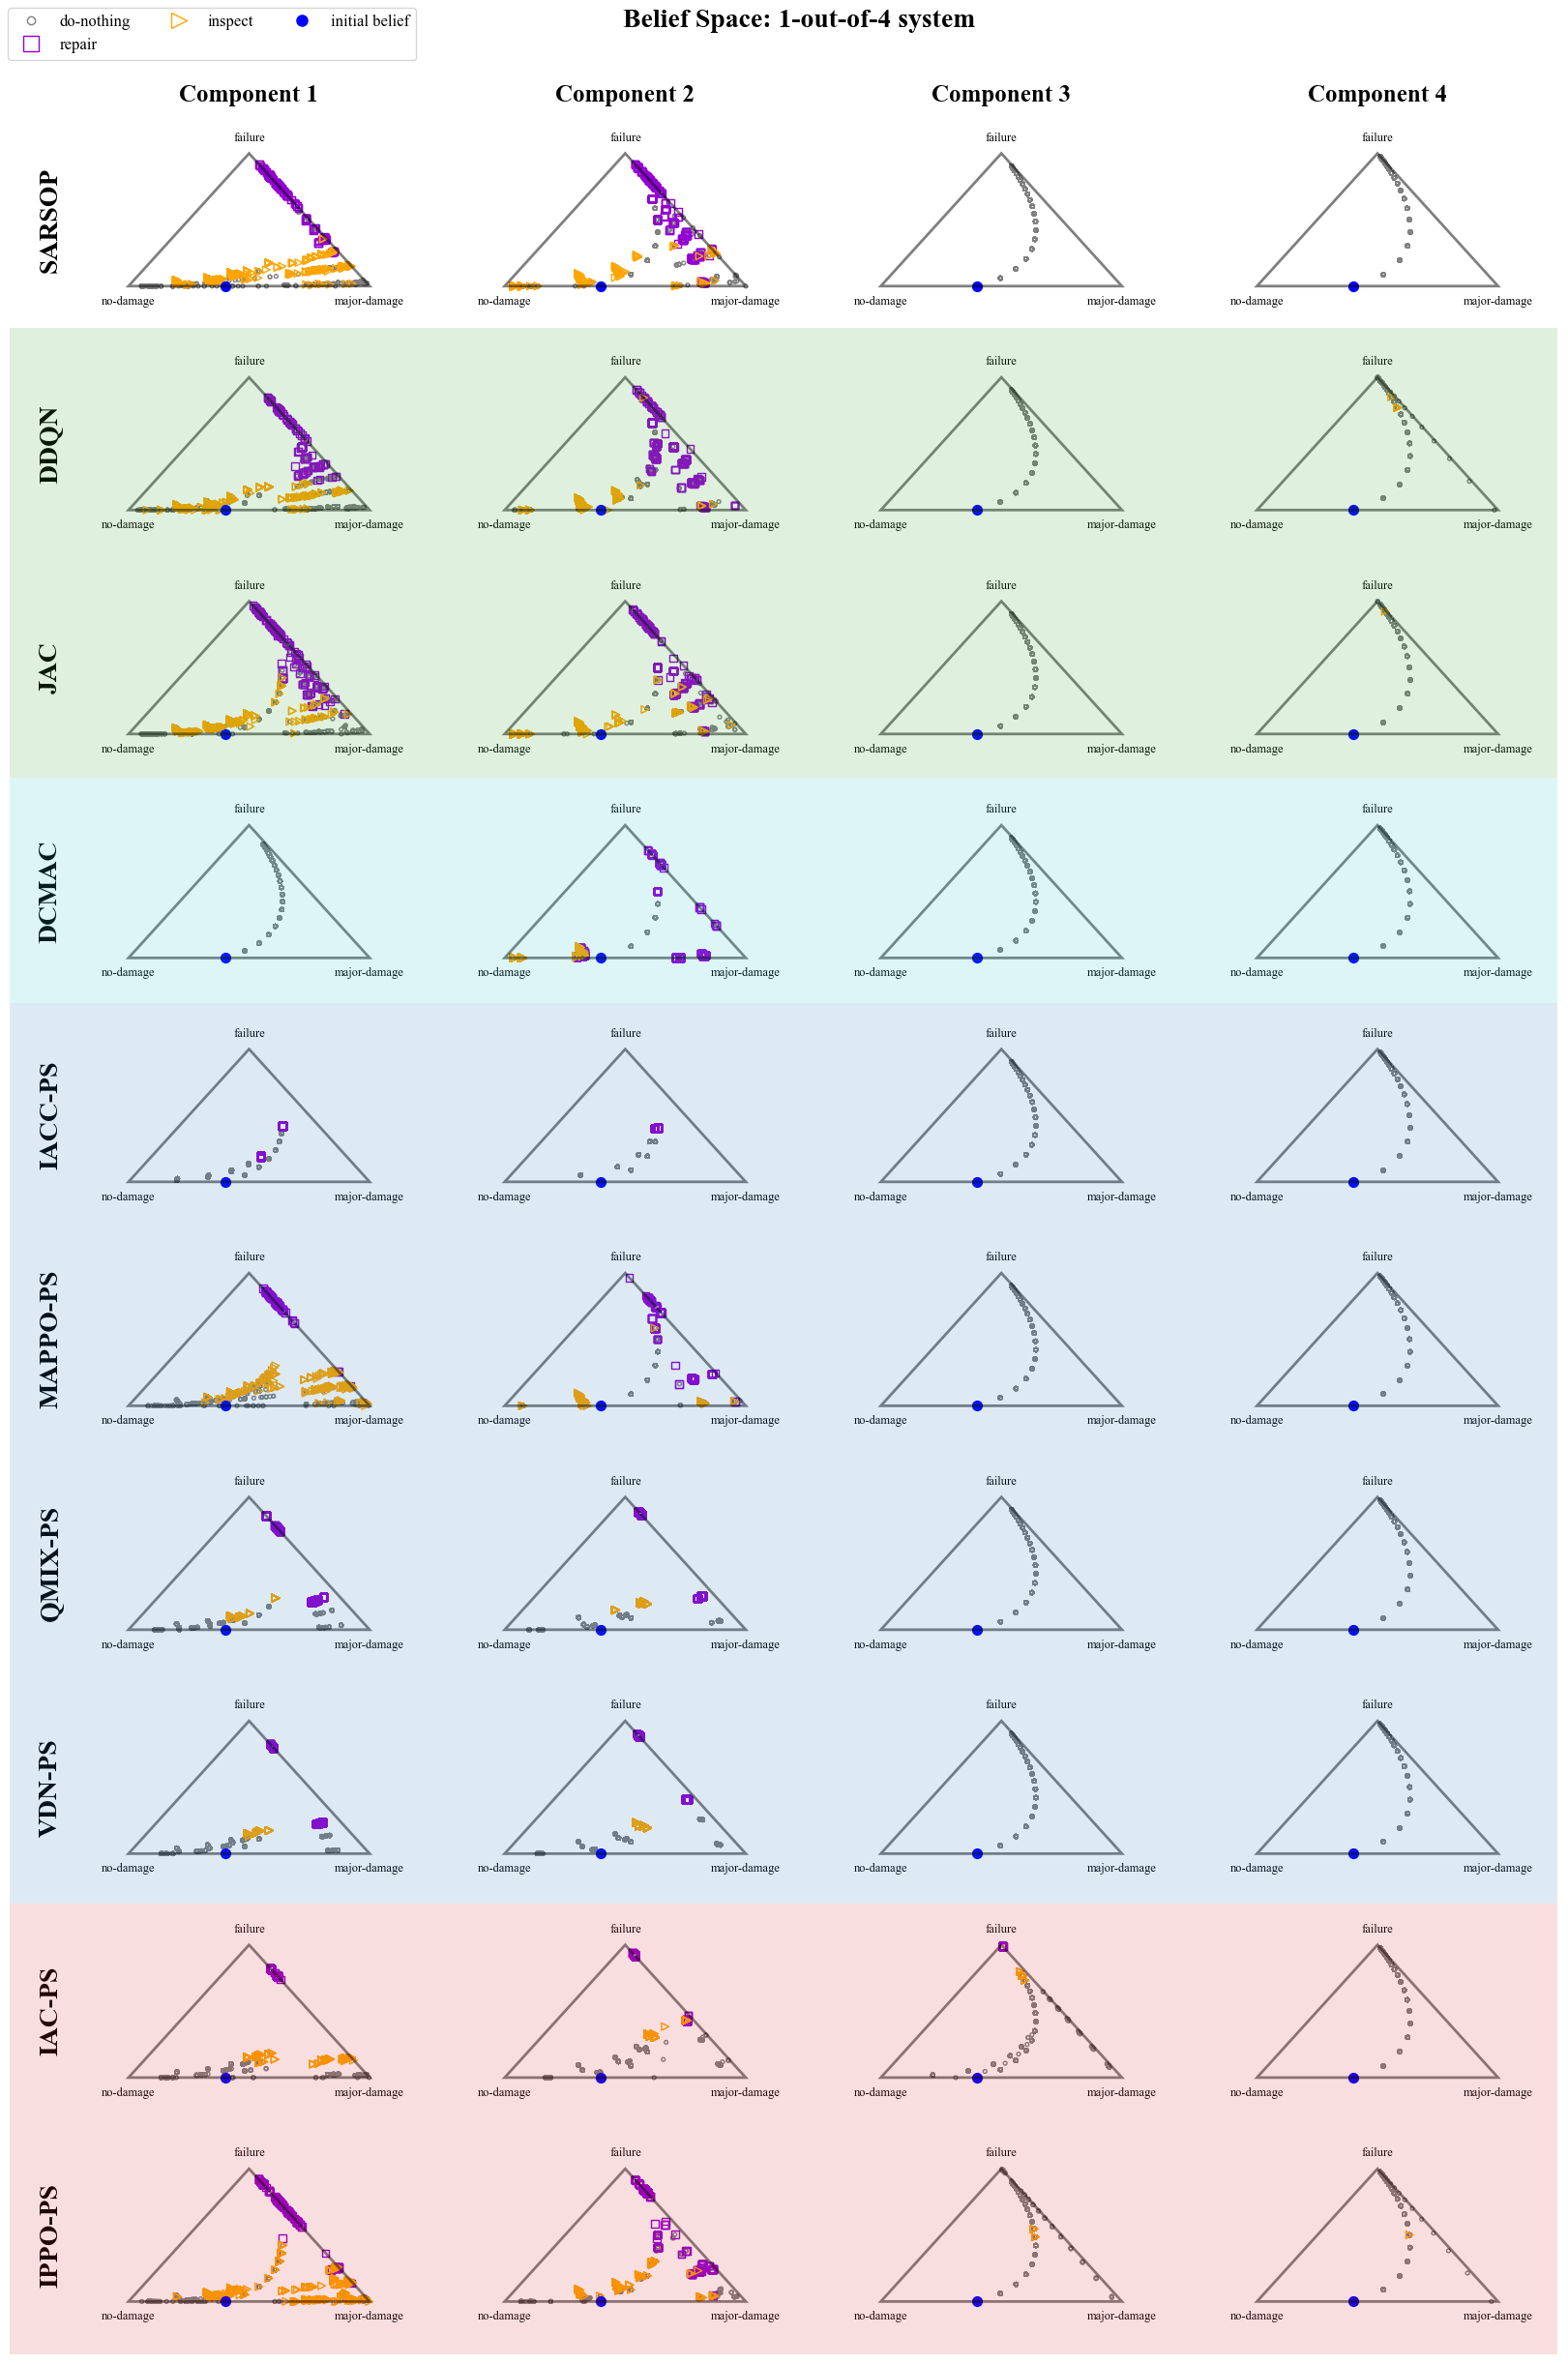

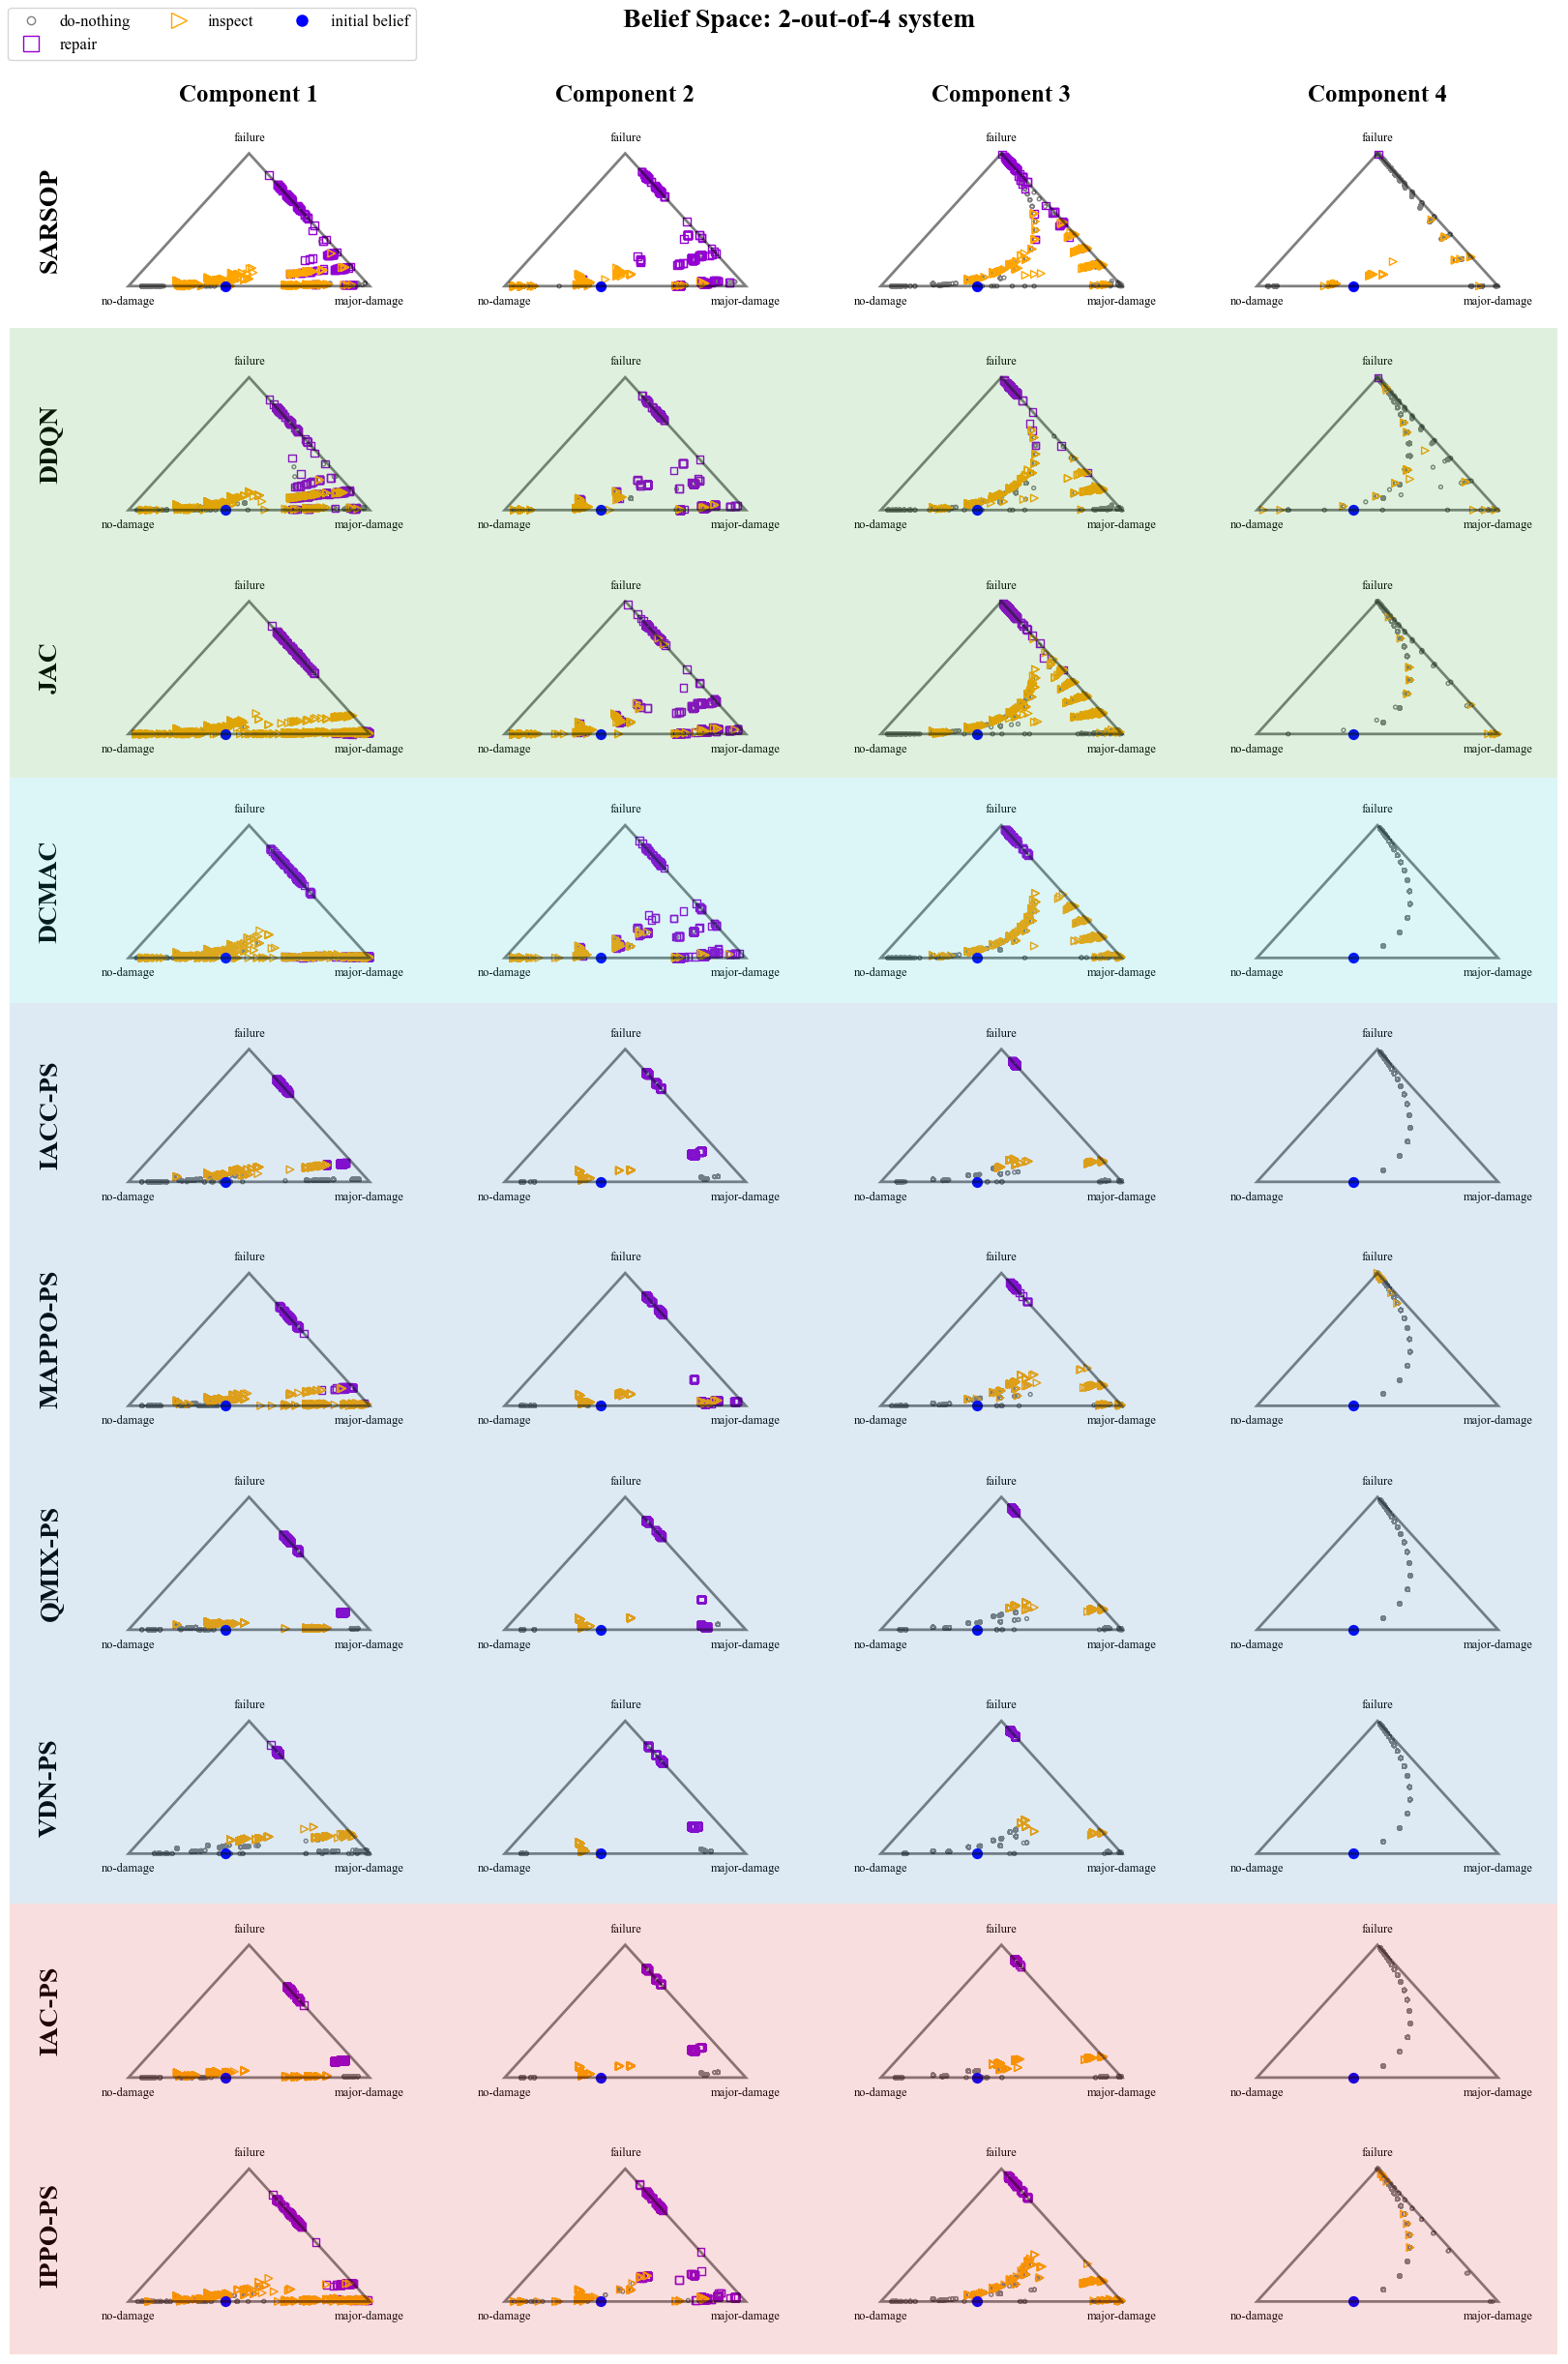

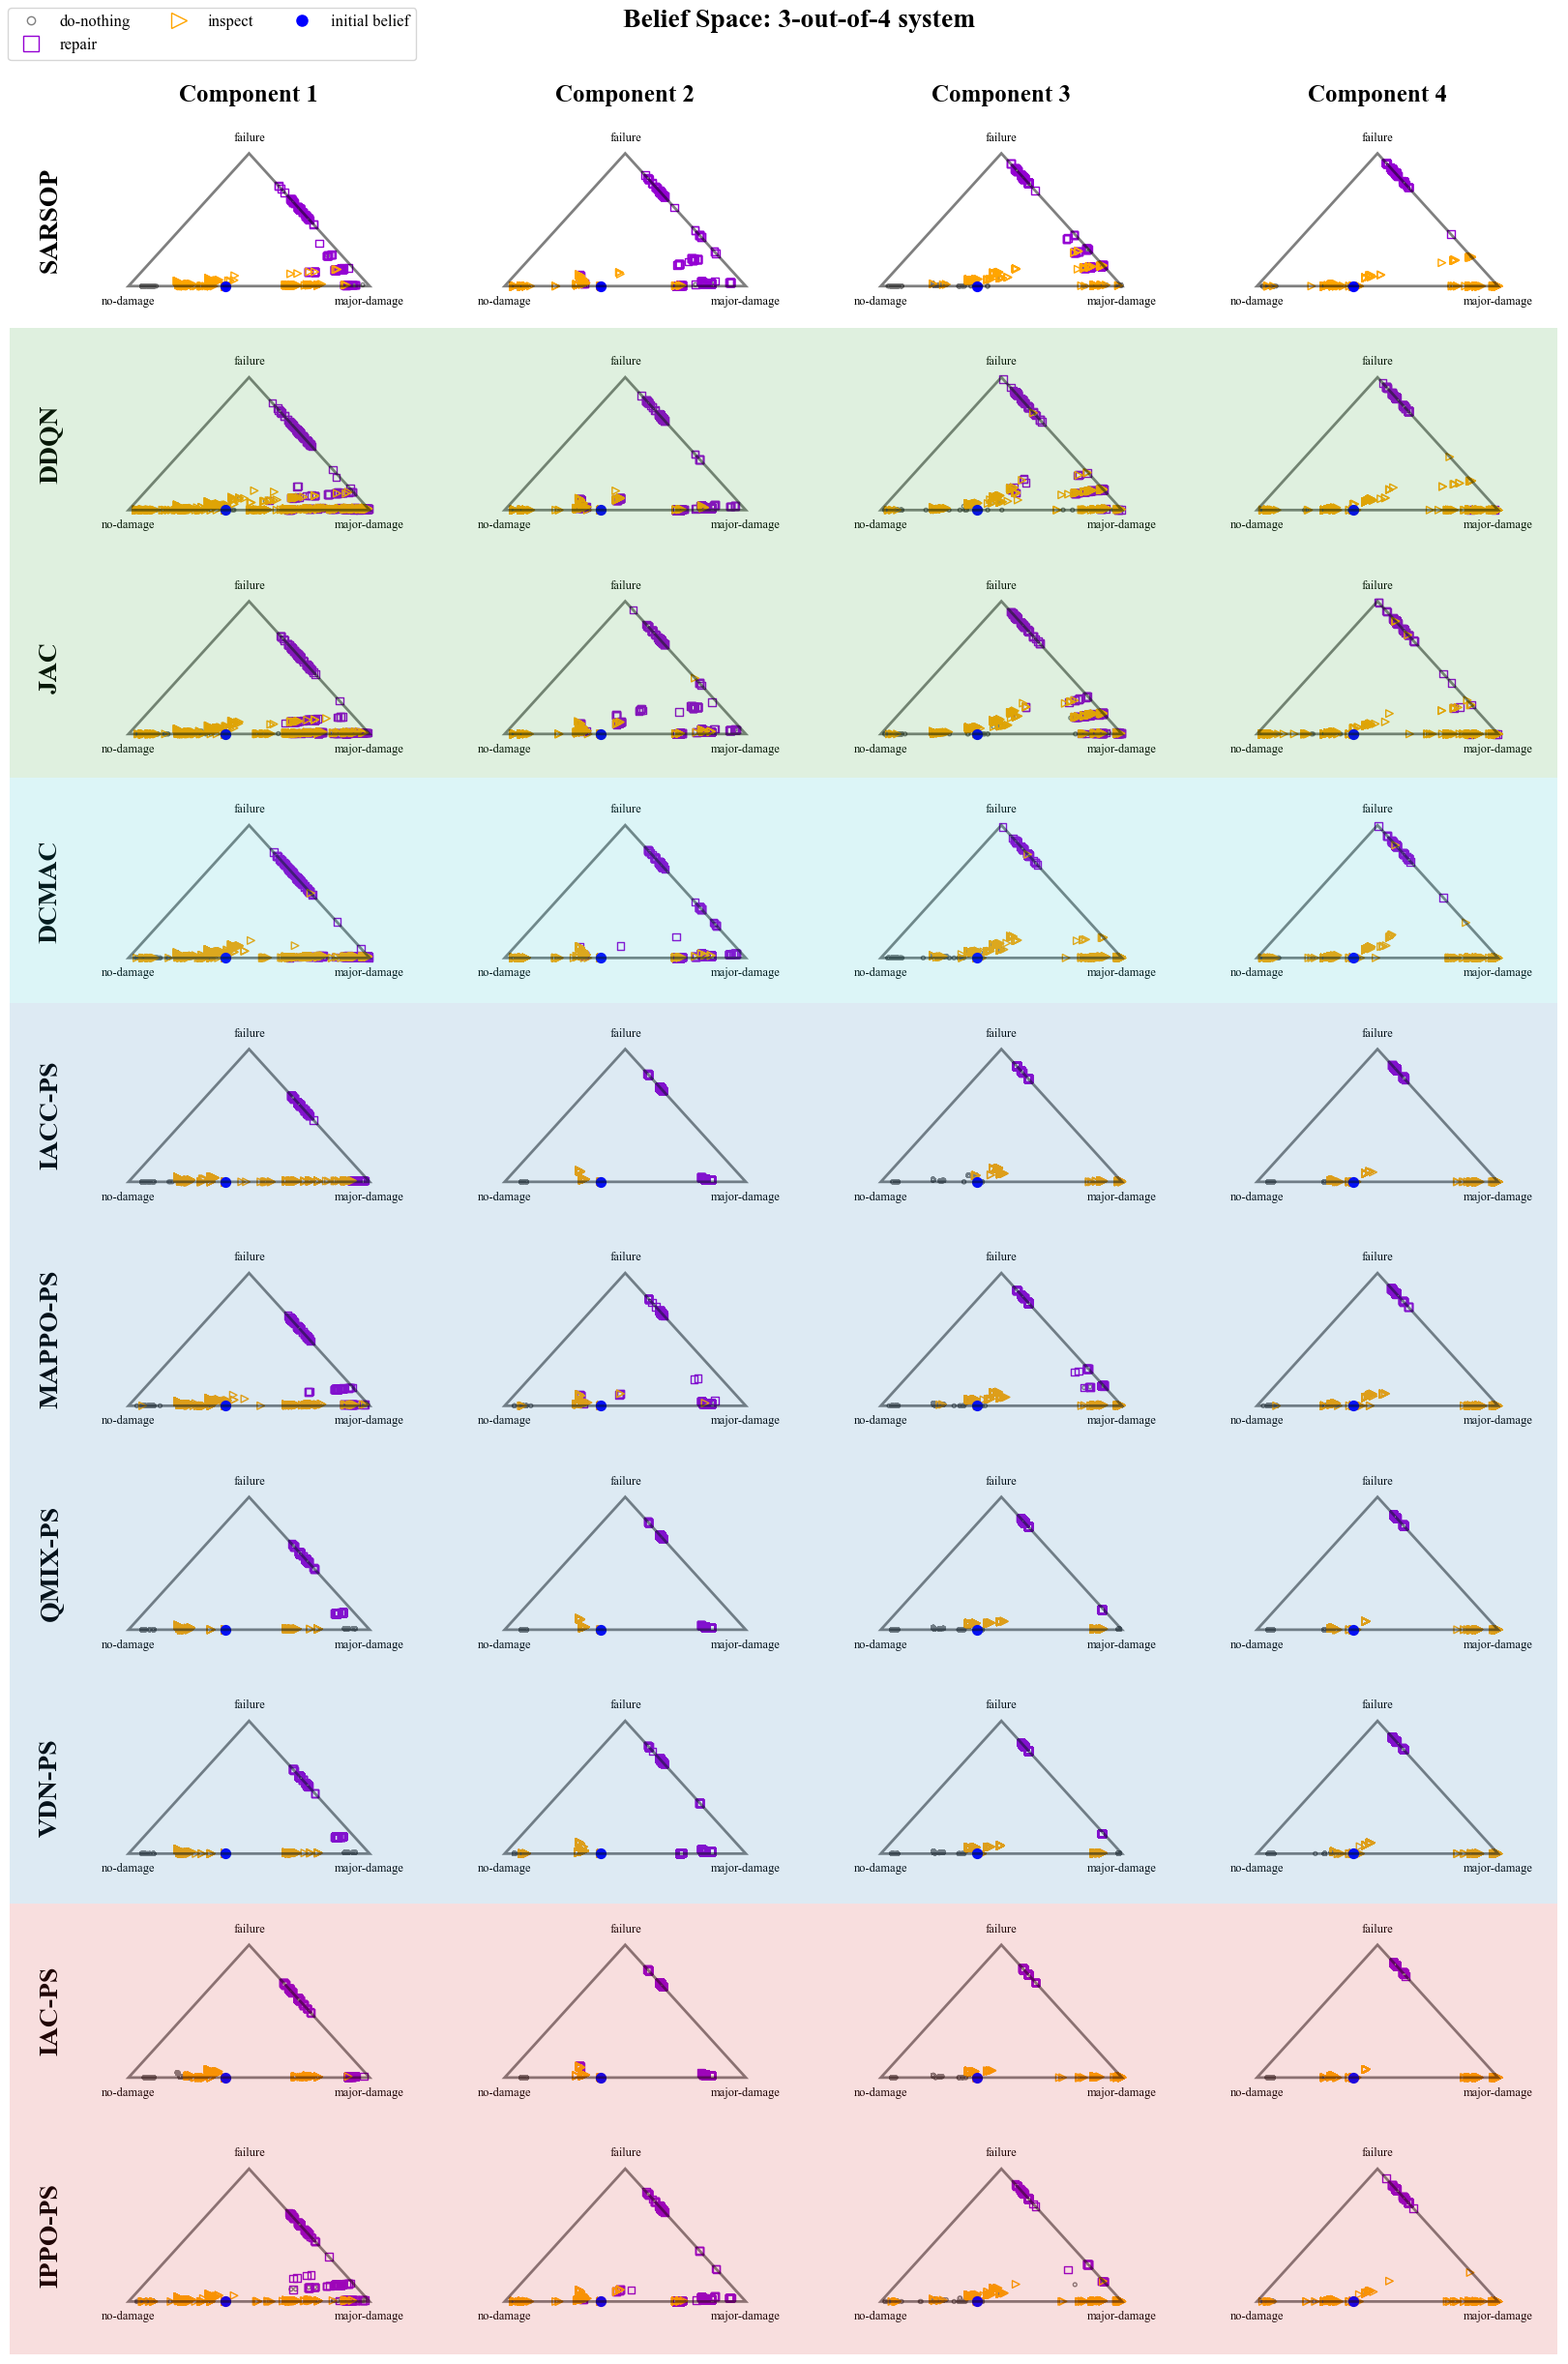

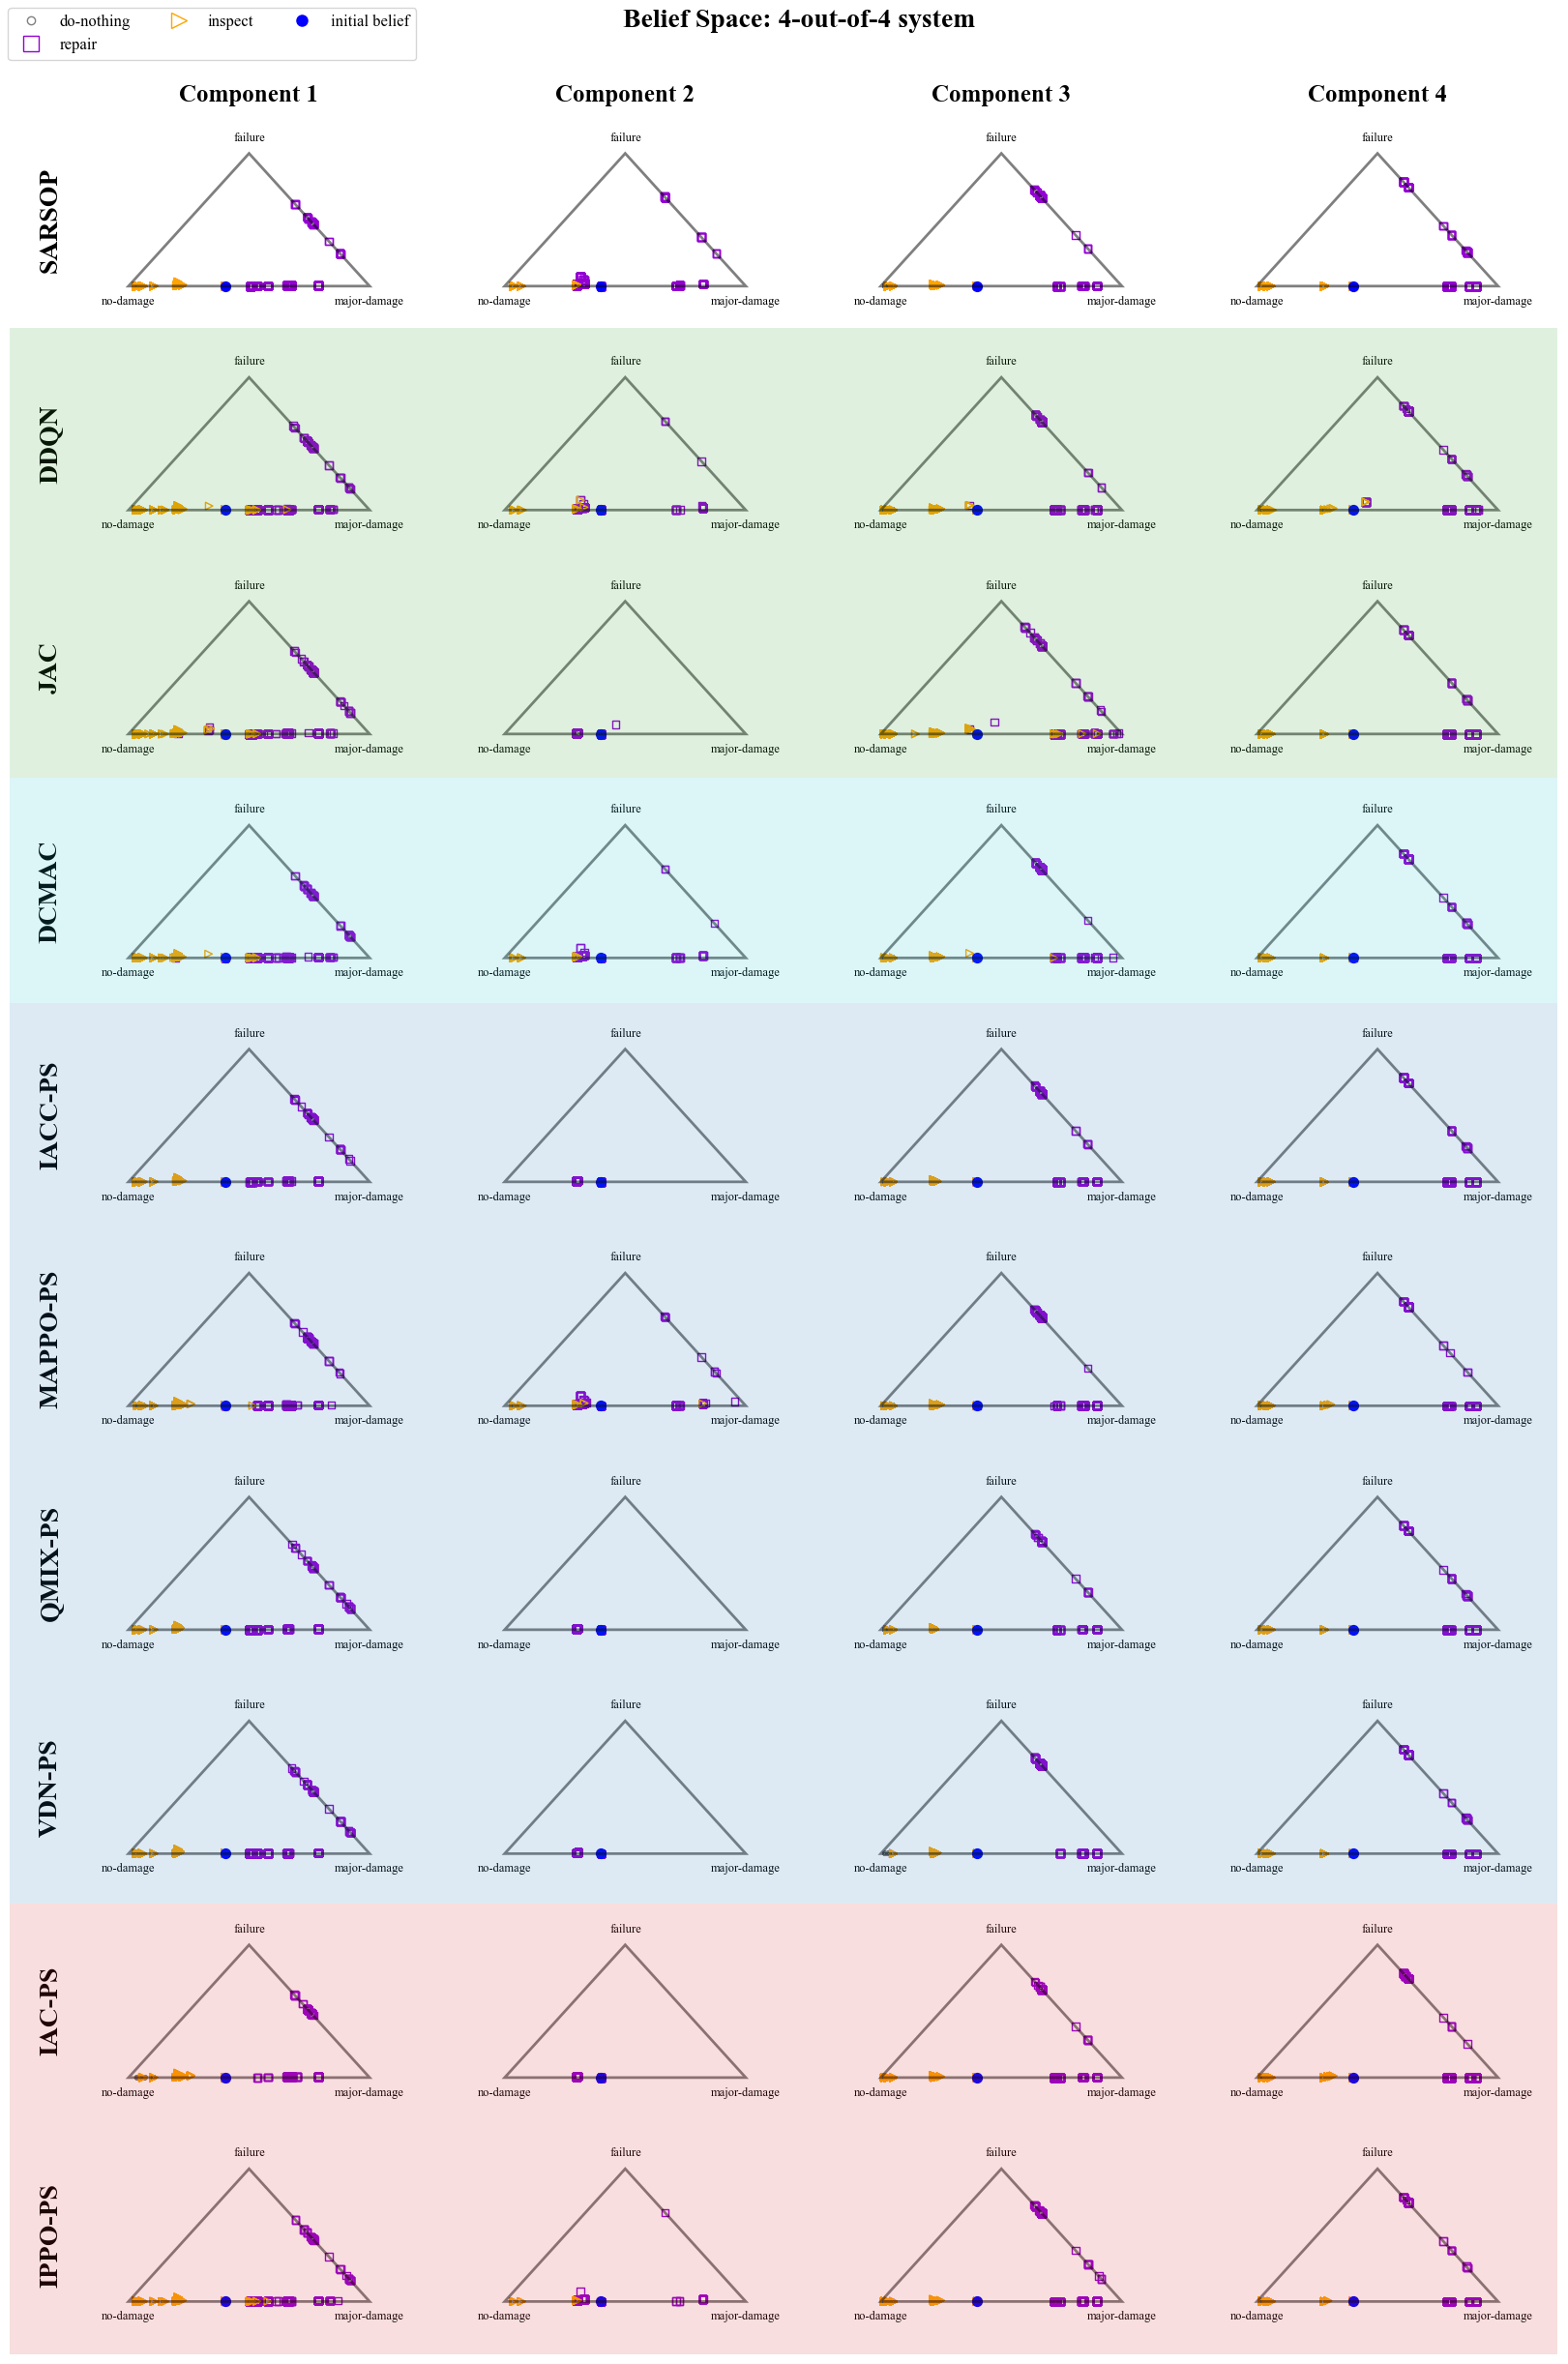

In [6]:
for env_setting in SETTINGS:
    plot_belief_space_with_actions(env_setting, save_fig=True)

## Plot specific timepoints

In [7]:
def plot_belief_space(env_setting, save_fig=False, num_trajectories=100):

    n_components = 4
    TIMEPOINTS = [0, 6, 12, 19, "all"]
    ALL_ALGORITHMS = ["SARSOP"] + ALGORITHMS
    ALL_ALGORITHMS_NAMES = ["SARSOP"] + ALGORITHM_NAMES
    fig, axs = plt.subplots(len(ALL_ALGORITHMS), len(TIMEPOINTS), figsize=(20, 24))

    component_labels = ["Component 1", "Component 2", "Component 3", "Component 4"]

    agent_colors = ["b", "g", "r", "gold"]

    _patch_alpha = 0.15

    # add plot for each timestep
    for a, alg in enumerate(ALL_ALGORITHMS_NAMES):

        # load and project once per algorithm row
        beliefs = load_rollout_data(env_setting, ALL_ALGORITHMS[a], "beliefs")
        n_traj = min(num_trajectories, beliefs.shape[0])
        beliefs = beliefs[:n_traj]
        tri_beliefs = beliefs @ CARTESIAN

        for i, t in enumerate(TIMEPOINTS):
            ax = axs[a, i]
            ax.set_facecolor("none")

            if t == "all":

                for c in range(n_components):
                    xy = tri_beliefs[:, :, c, :].reshape(-1, 2)

                    ax.scatter(
                        xy[:, 0],
                        xy[:, 1],
                        color=agent_colors[c],
                        marker="o",
                        s=12,
                        label=component_labels[c],
                    )

                # set title for first row
                if a == 0:
                    ax.set_title("all", fontsize=20, fontweight="bold", pad=10)
            else:
                # plot beliefs for each component
                t_idx = min(t, tri_beliefs.shape[1] - 1)
                for c in range(n_components):
                    xy = tri_beliefs[:, t_idx, c, :]
                    ax.scatter(
                        xy[:, 0],
                        xy[:, 1],
                        color=agent_colors[c],
                        marker="o",
                        s=15,
                        label=component_labels[c],
                    )

                # set title for first row
                if a == 0:
                    ax.set_title(f"t = {t}", fontsize=20, fontweight="bold", pad=10)

            # y label for each row
            if i == 0:
                ax.set_ylabel(f"{alg}", fontsize=20, fontweight="bold")

            # Add the triangle to the plot
            triangle = Polygon(
                CARTESIAN, closed=True, edgecolor="k", fill=None, alpha=0.5, linewidth=2
            )
            ax.add_patch(triangle)
            ax.set_xlim(-0.25, 1.25)
            ax.set_ylim(-0.25, 0.8666 + 0.25)
            ax.text(0.0, -0.1, "(1,0,0)", fontsize=10, ha="center", va="center")
            ax.text(1.0, -0.1, "(0,1,0)", fontsize=10, ha="center", va="center")
            ax.text(0.5, 0.8666 + 0.1, "(0,0,1)", fontsize=10, ha="center", va="center")

            # Remove all spines
            for spine in ax.spines.values():
                spine.set_visible(False)

            # Remove x and y ticks
            ax.set_xticks([])
            ax.set_yticks([])

    i = SETTINGS.index(env_setting)
    fig.suptitle(
        f"Belief Occupancy: {SETTING_NAMES[i]} system",
        fontsize=20,
        y=1.05,
        fontweight="bold",
        position=(0.5, 1.01),
    )

    legend_items = [
        plt.Line2D(
            [0], [0], marker="o", color="w", markerfacecolor=color, markersize=10
        )
        for color in agent_colors
    ]
    fig.legend(legend_items, component_labels, loc="upper right", ncol=2, fontsize=12)

    plt.tight_layout()
    fig.canvas.draw()

    # row-aligned background bands in figure coordinates
    def _add_row_band(r0, r1, color):
        y_top = axs[r0, 0].get_position().y1
        y_bot = axs[r1, 0].get_position().y0
        fig.patches.append(
            Rectangle(
                (0.0, y_bot),
                1.0,
                y_top - y_bot,
                transform=fig.transFigure,
                facecolor=color,
                alpha=_patch_alpha,
                zorder=-10,
                clip_on=False,
            )
        )

    # Keep SARSOP row unshaded; shade model families below.
    _add_row_band(1, 3, "tab:green")
    _add_row_band(4, 4, "tab:cyan")
    _add_row_band(5, 7, "tab:blue")
    _add_row_band(8, 9, "tab:red")

    plt.show()

    if save_fig:
        fig.savefig(
            f"figures/belief_space-{env_setting}.png", bbox_inches="tight", dpi=300
        )


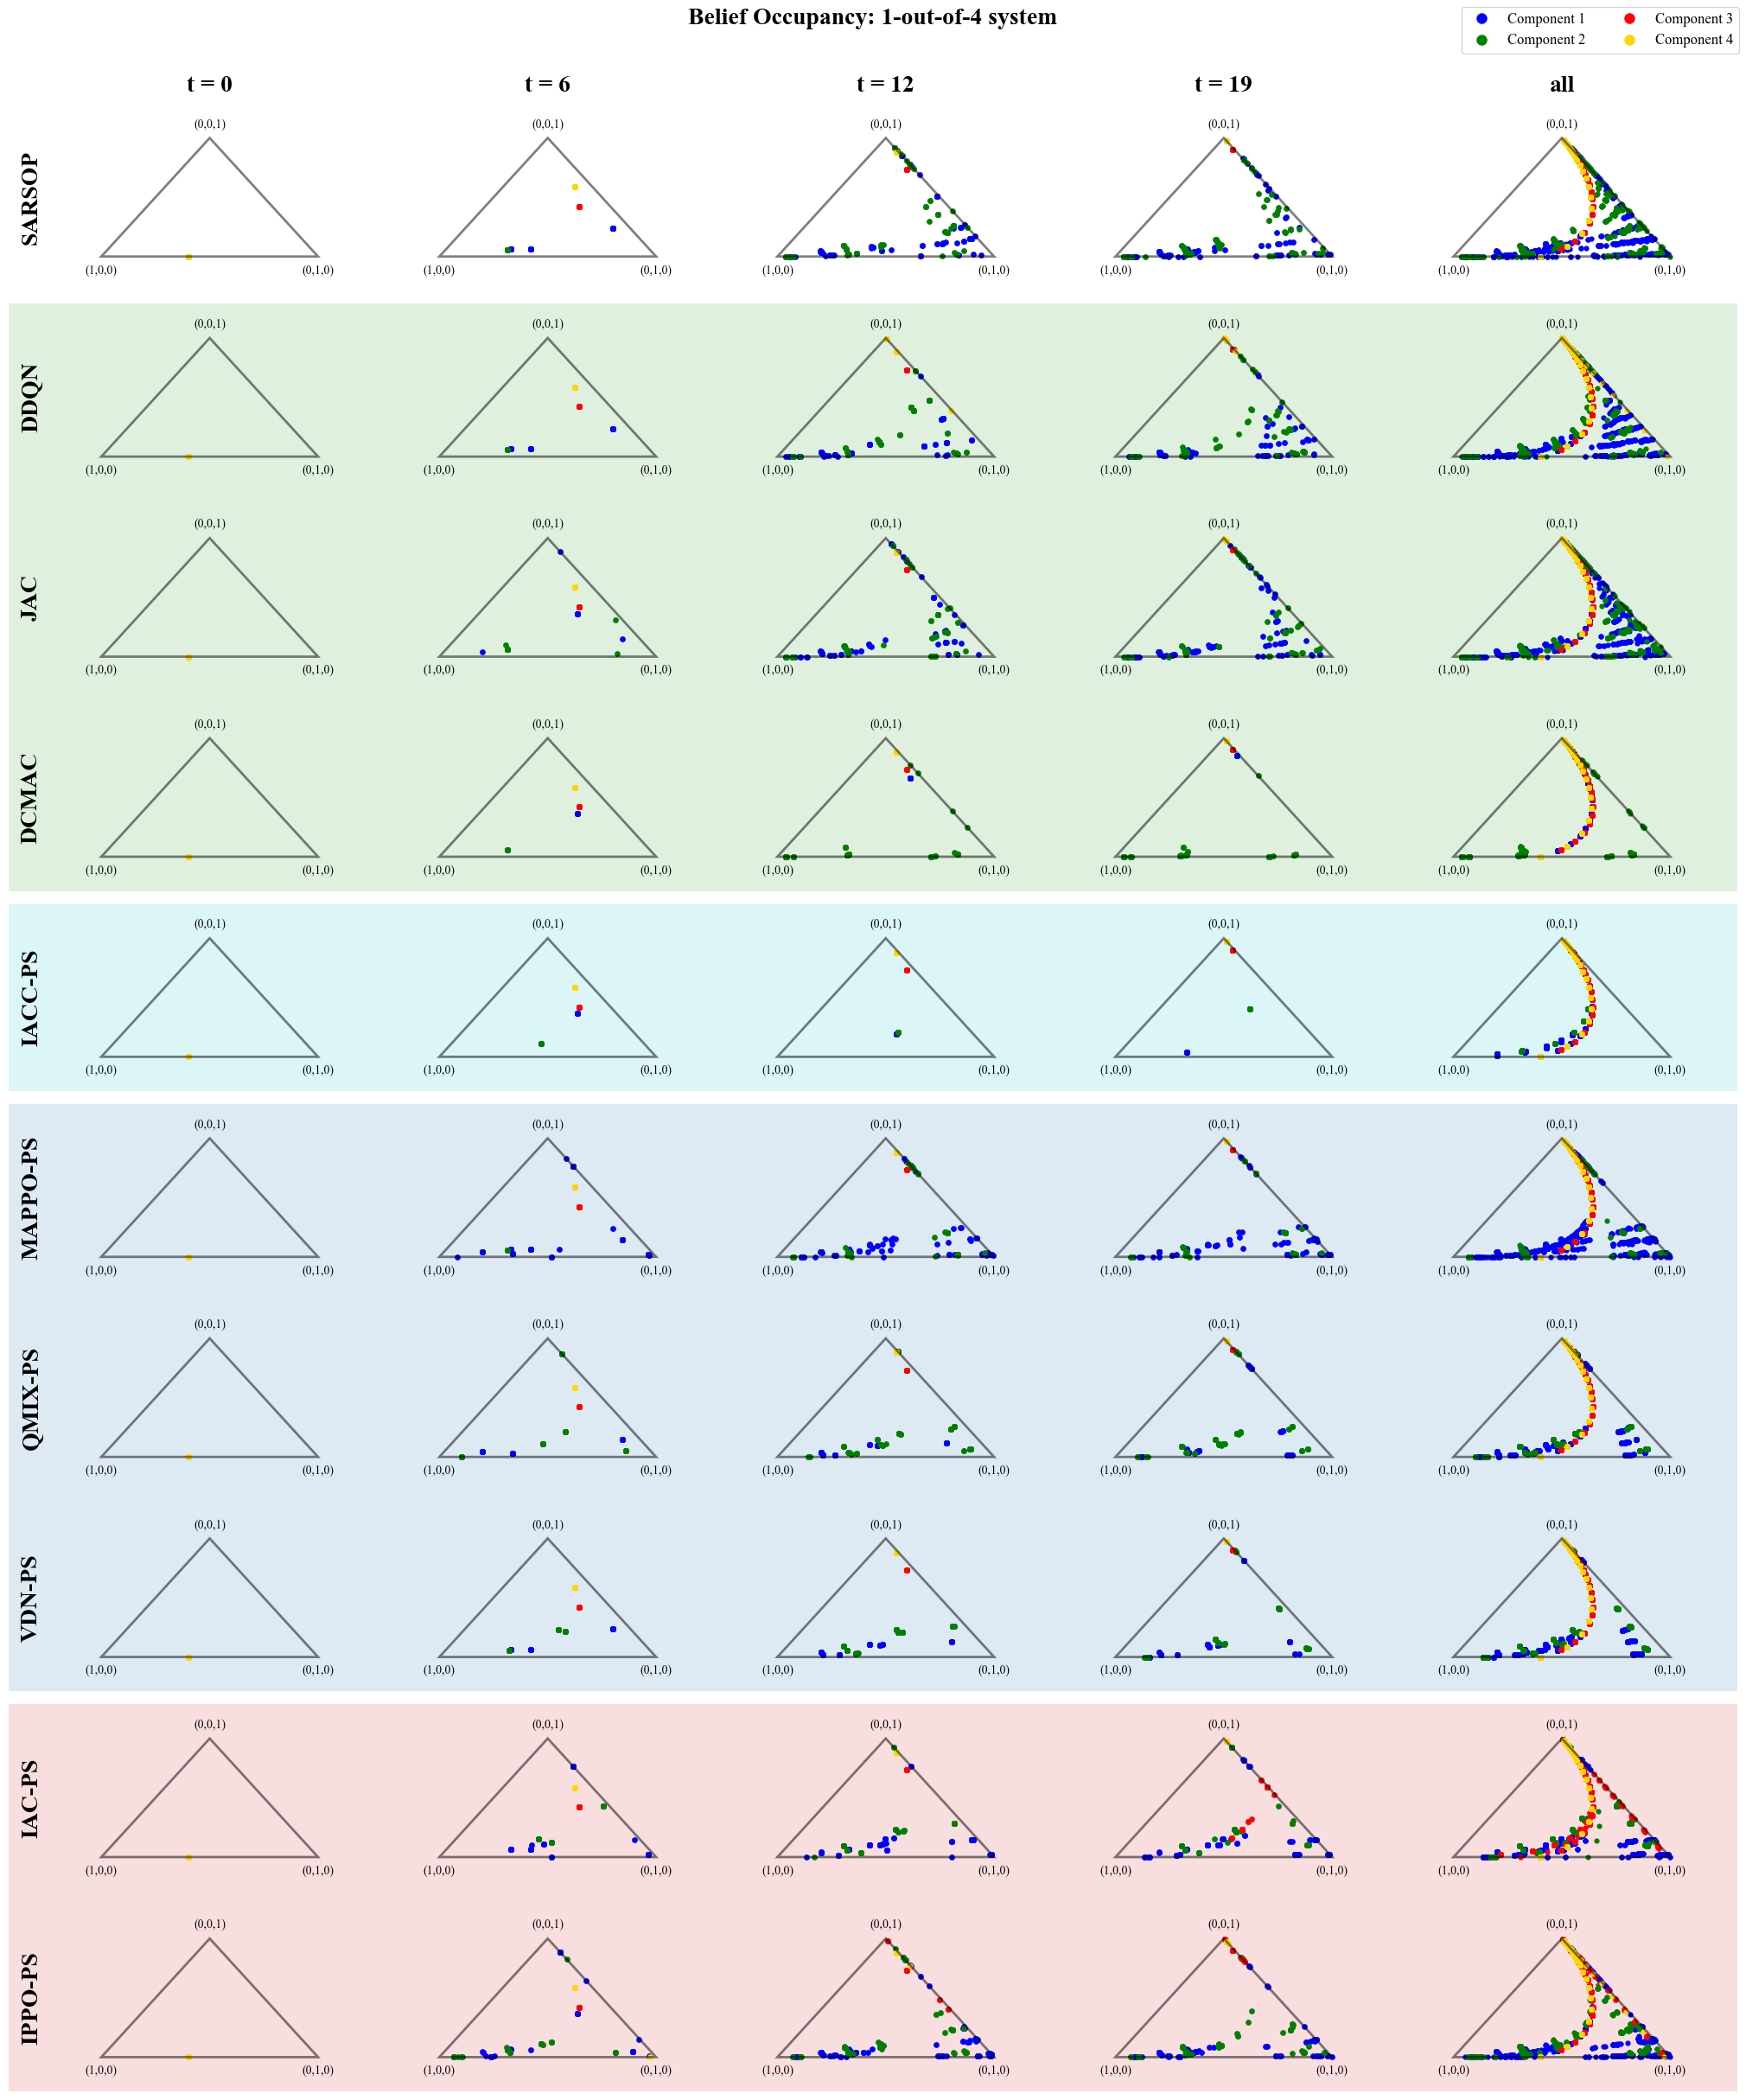

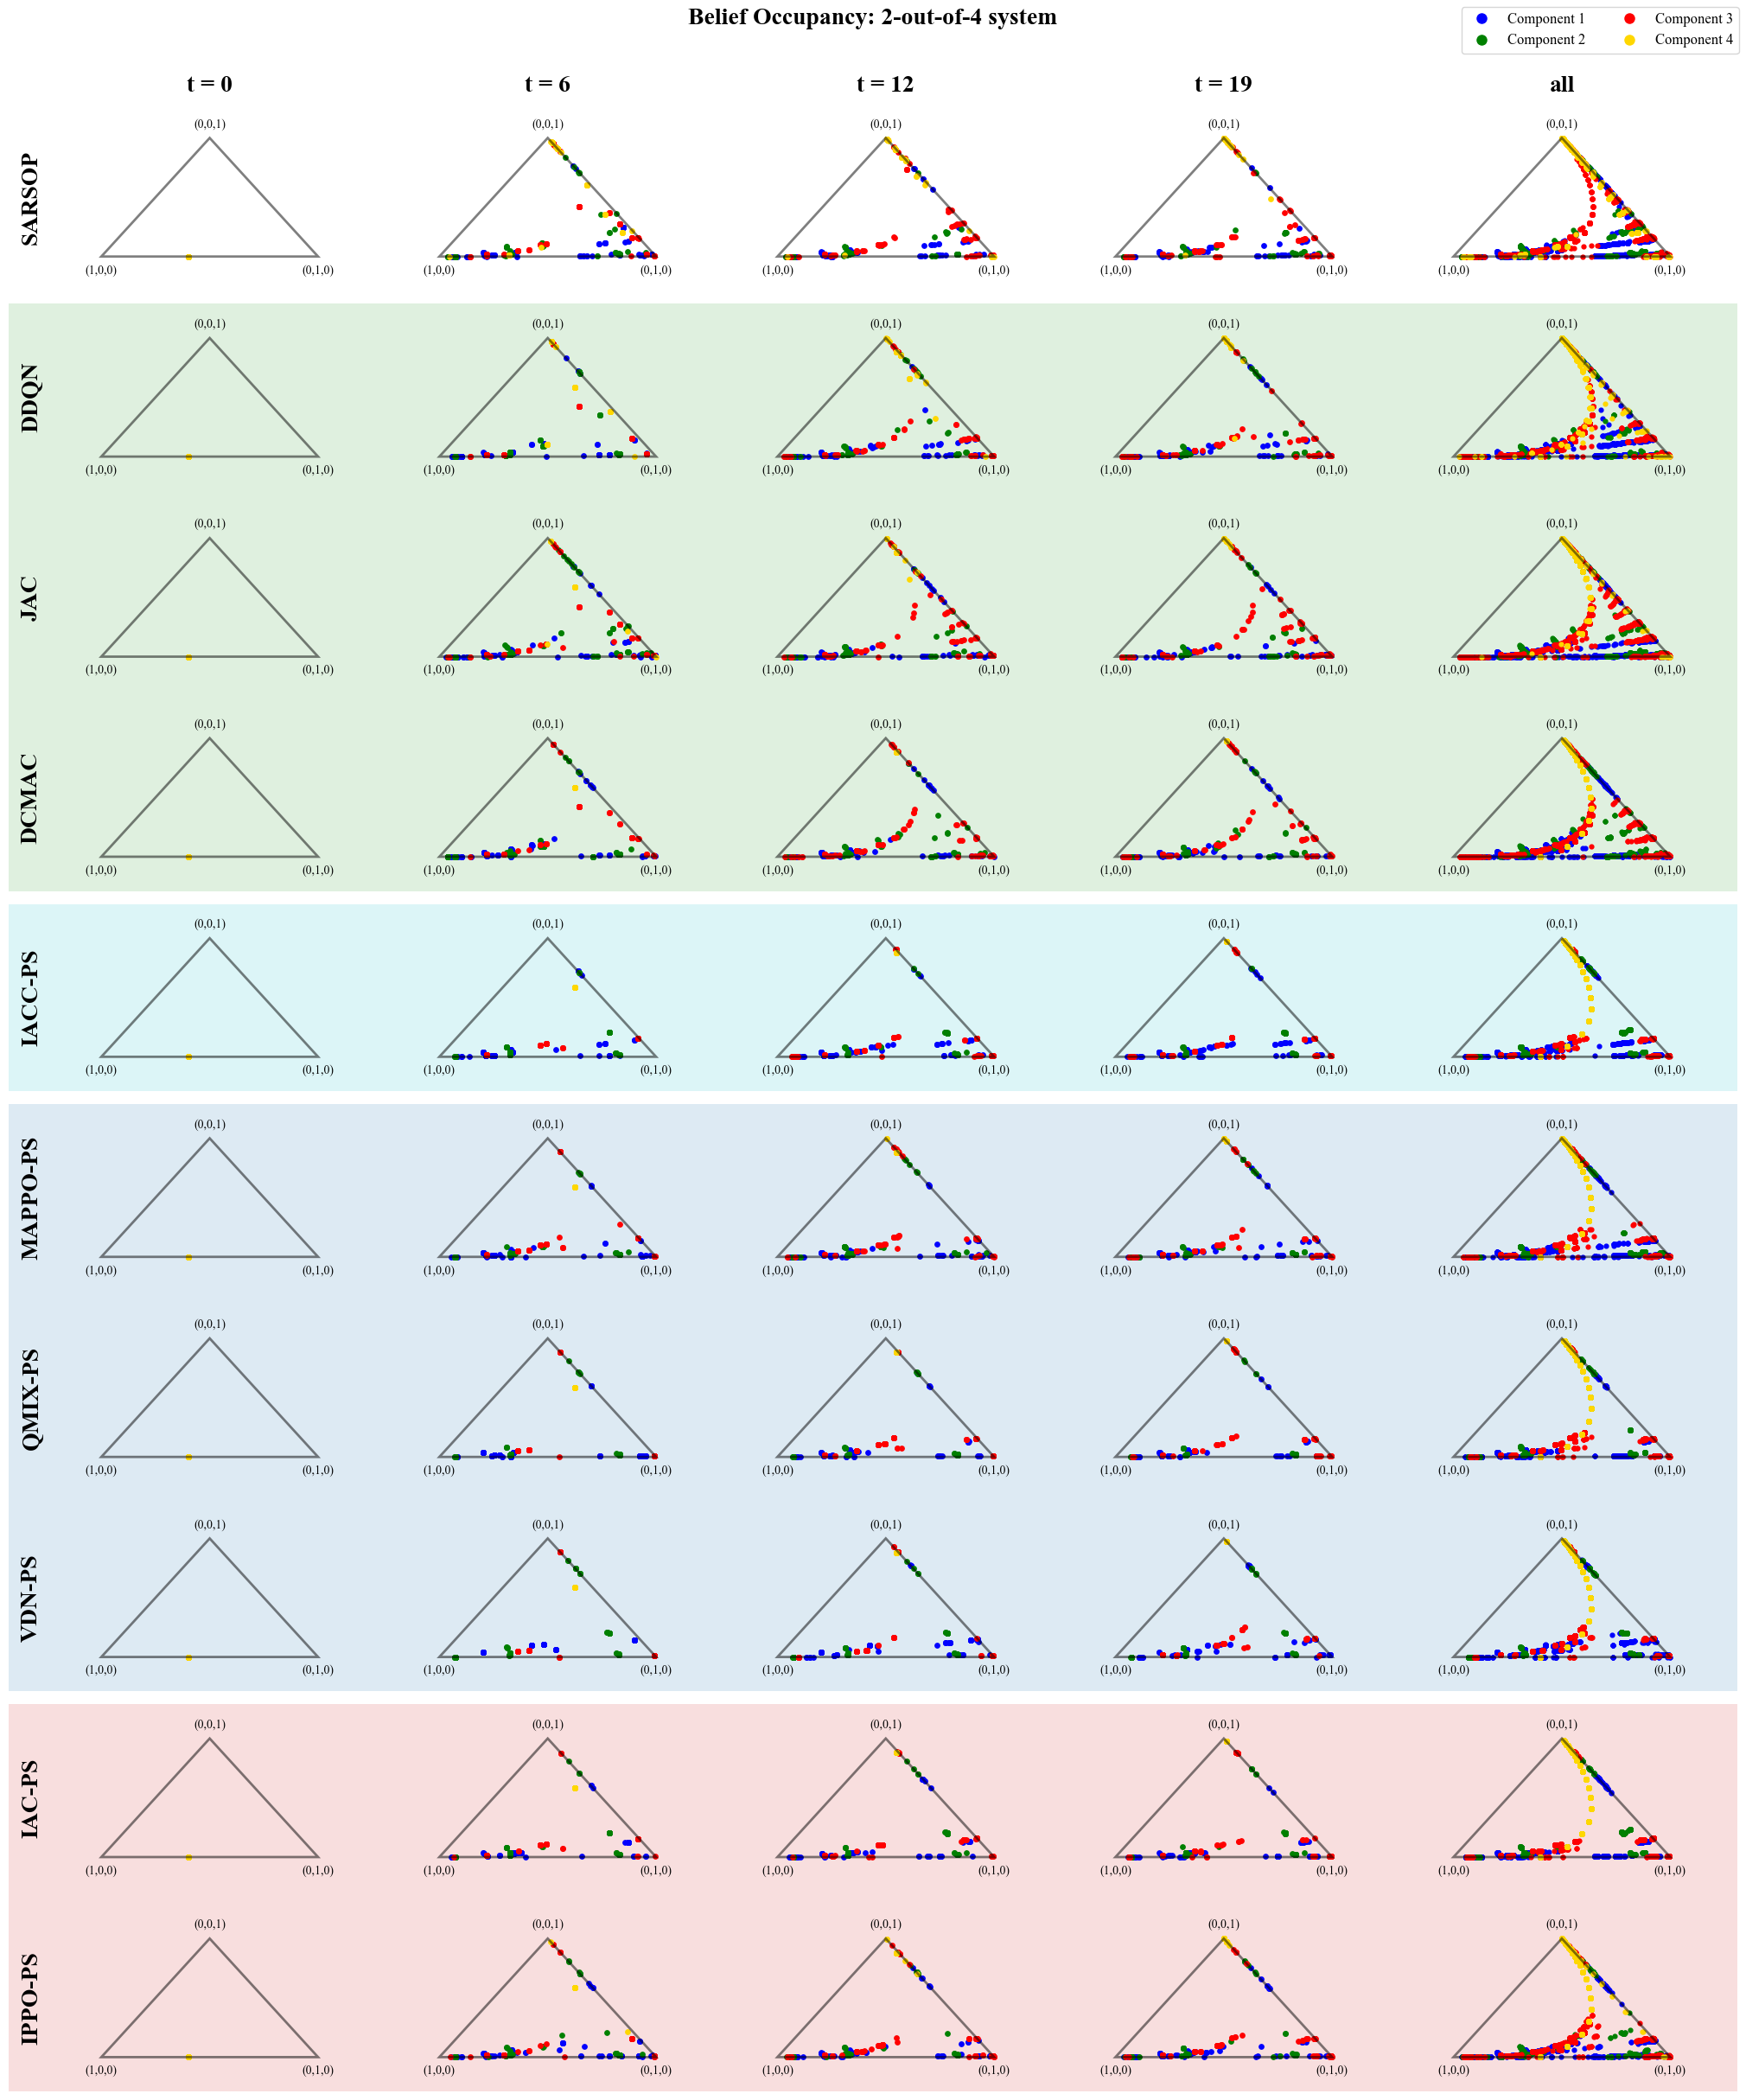

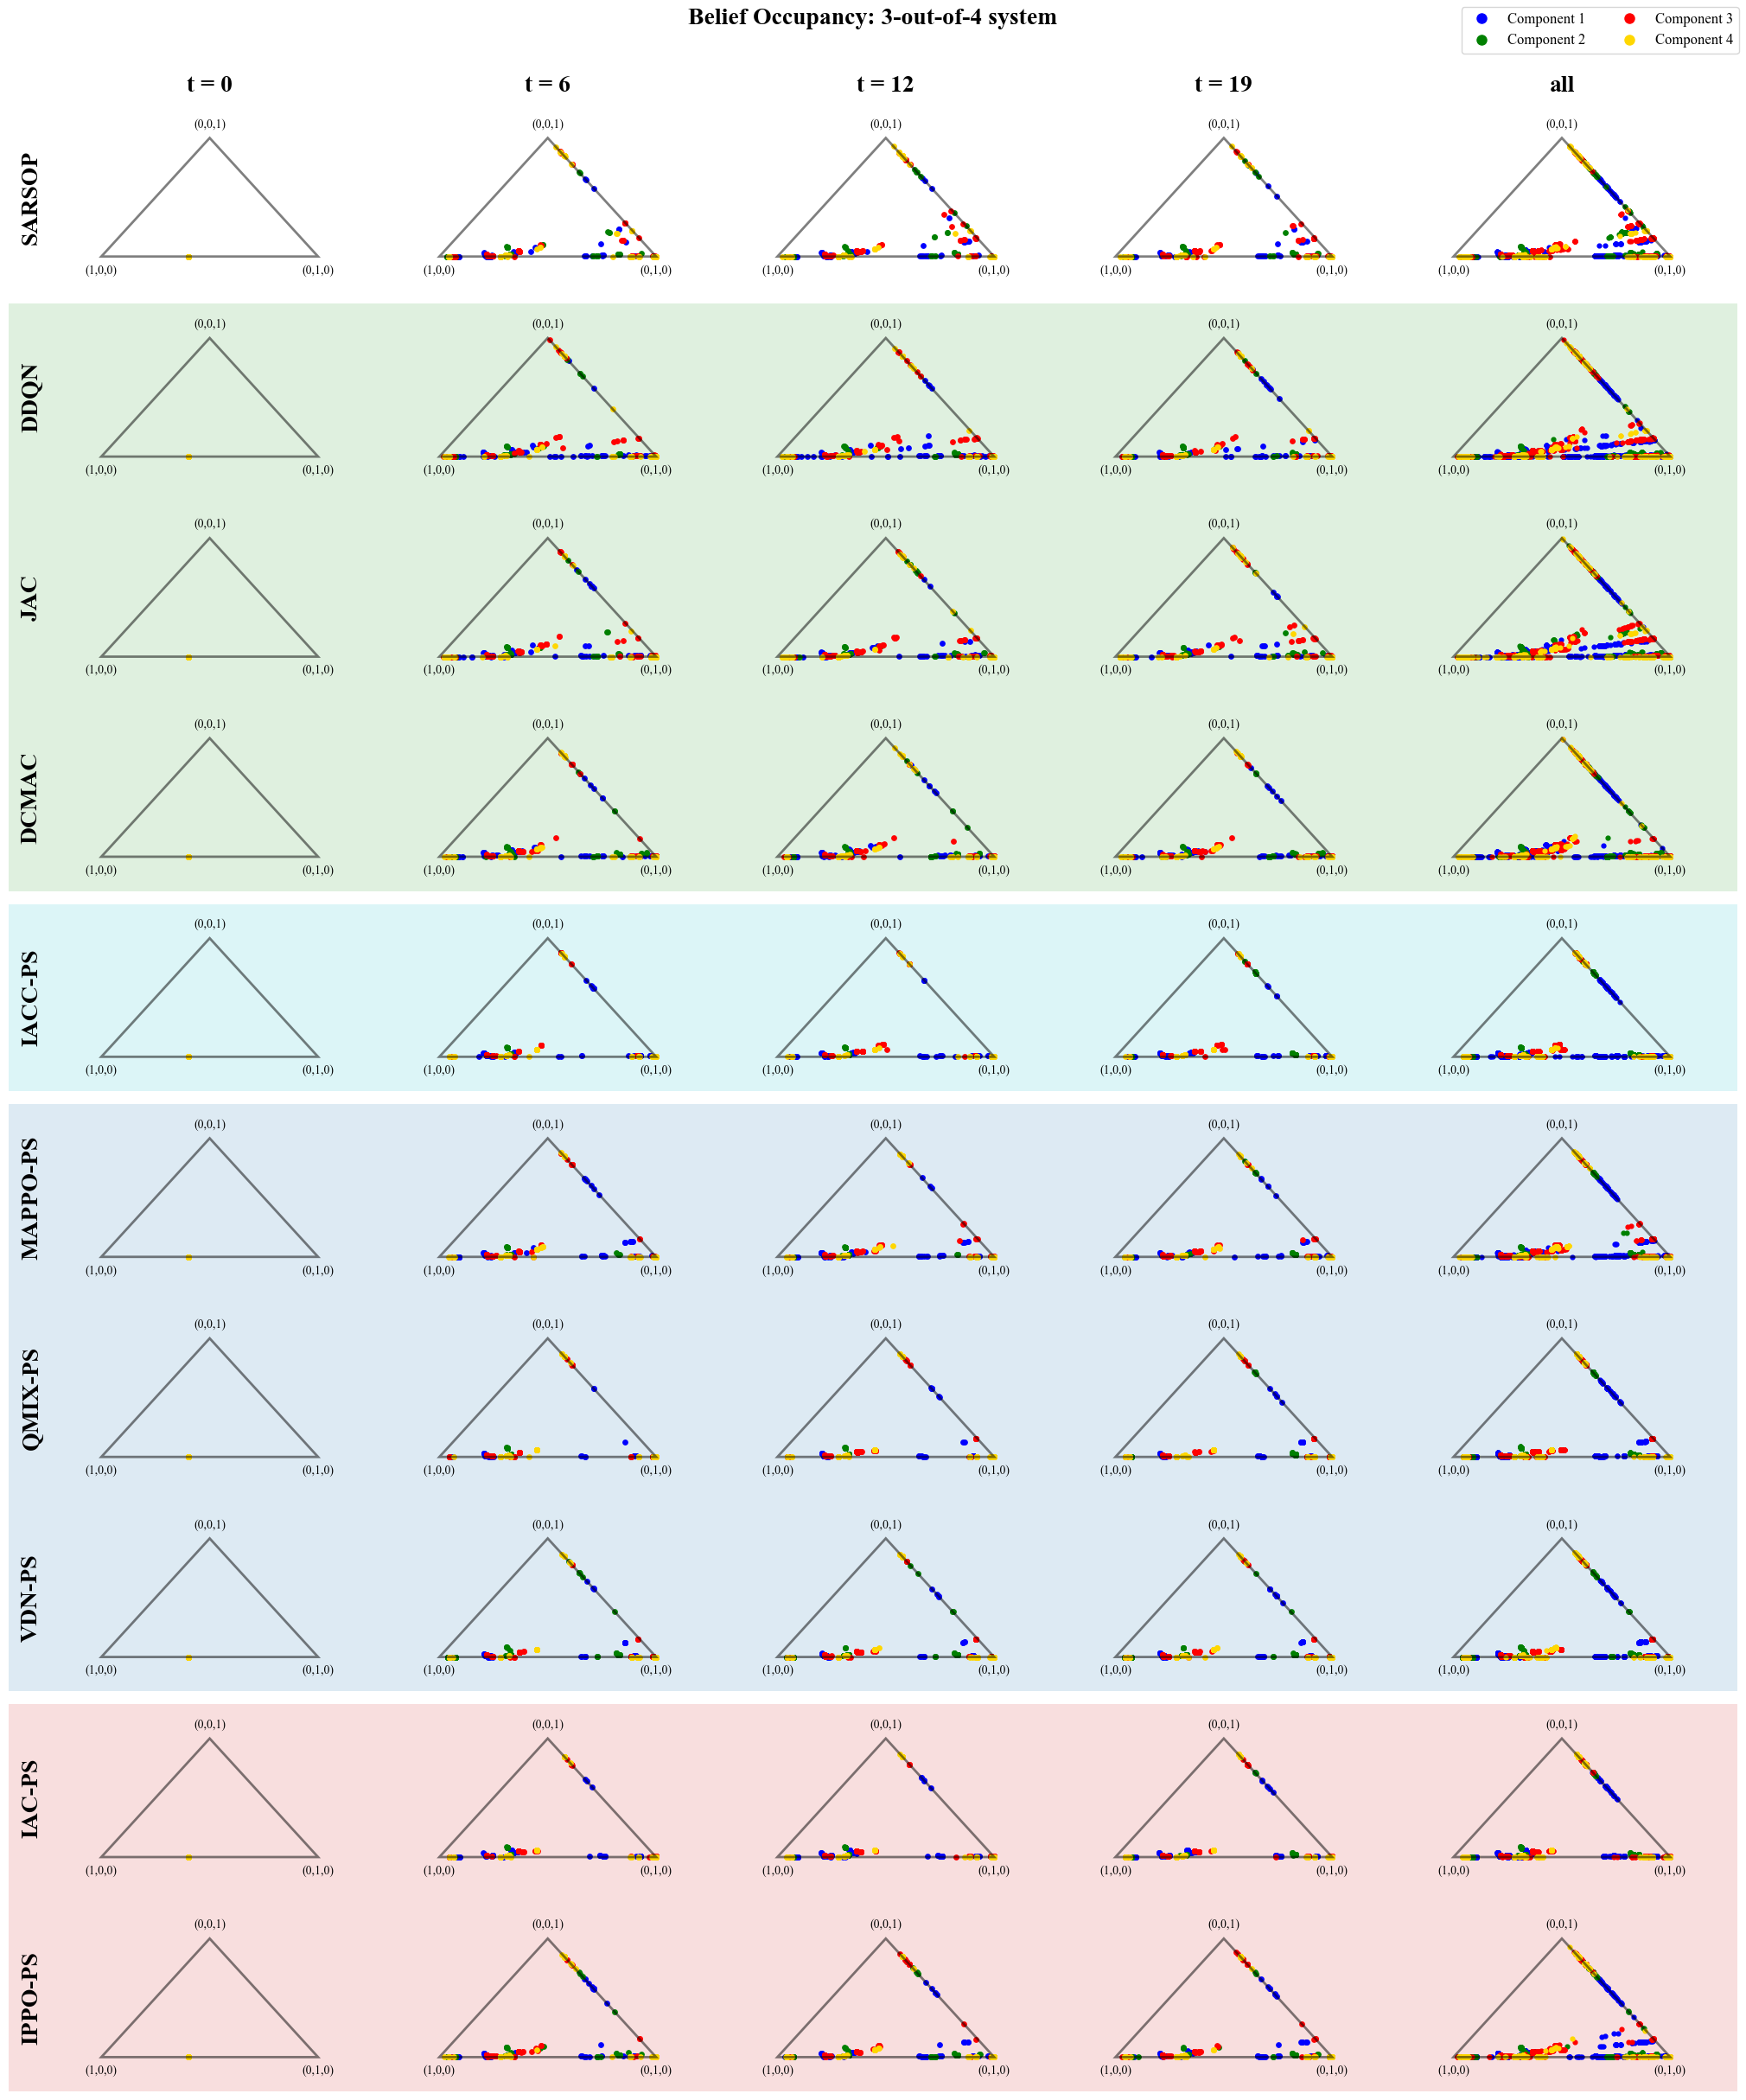

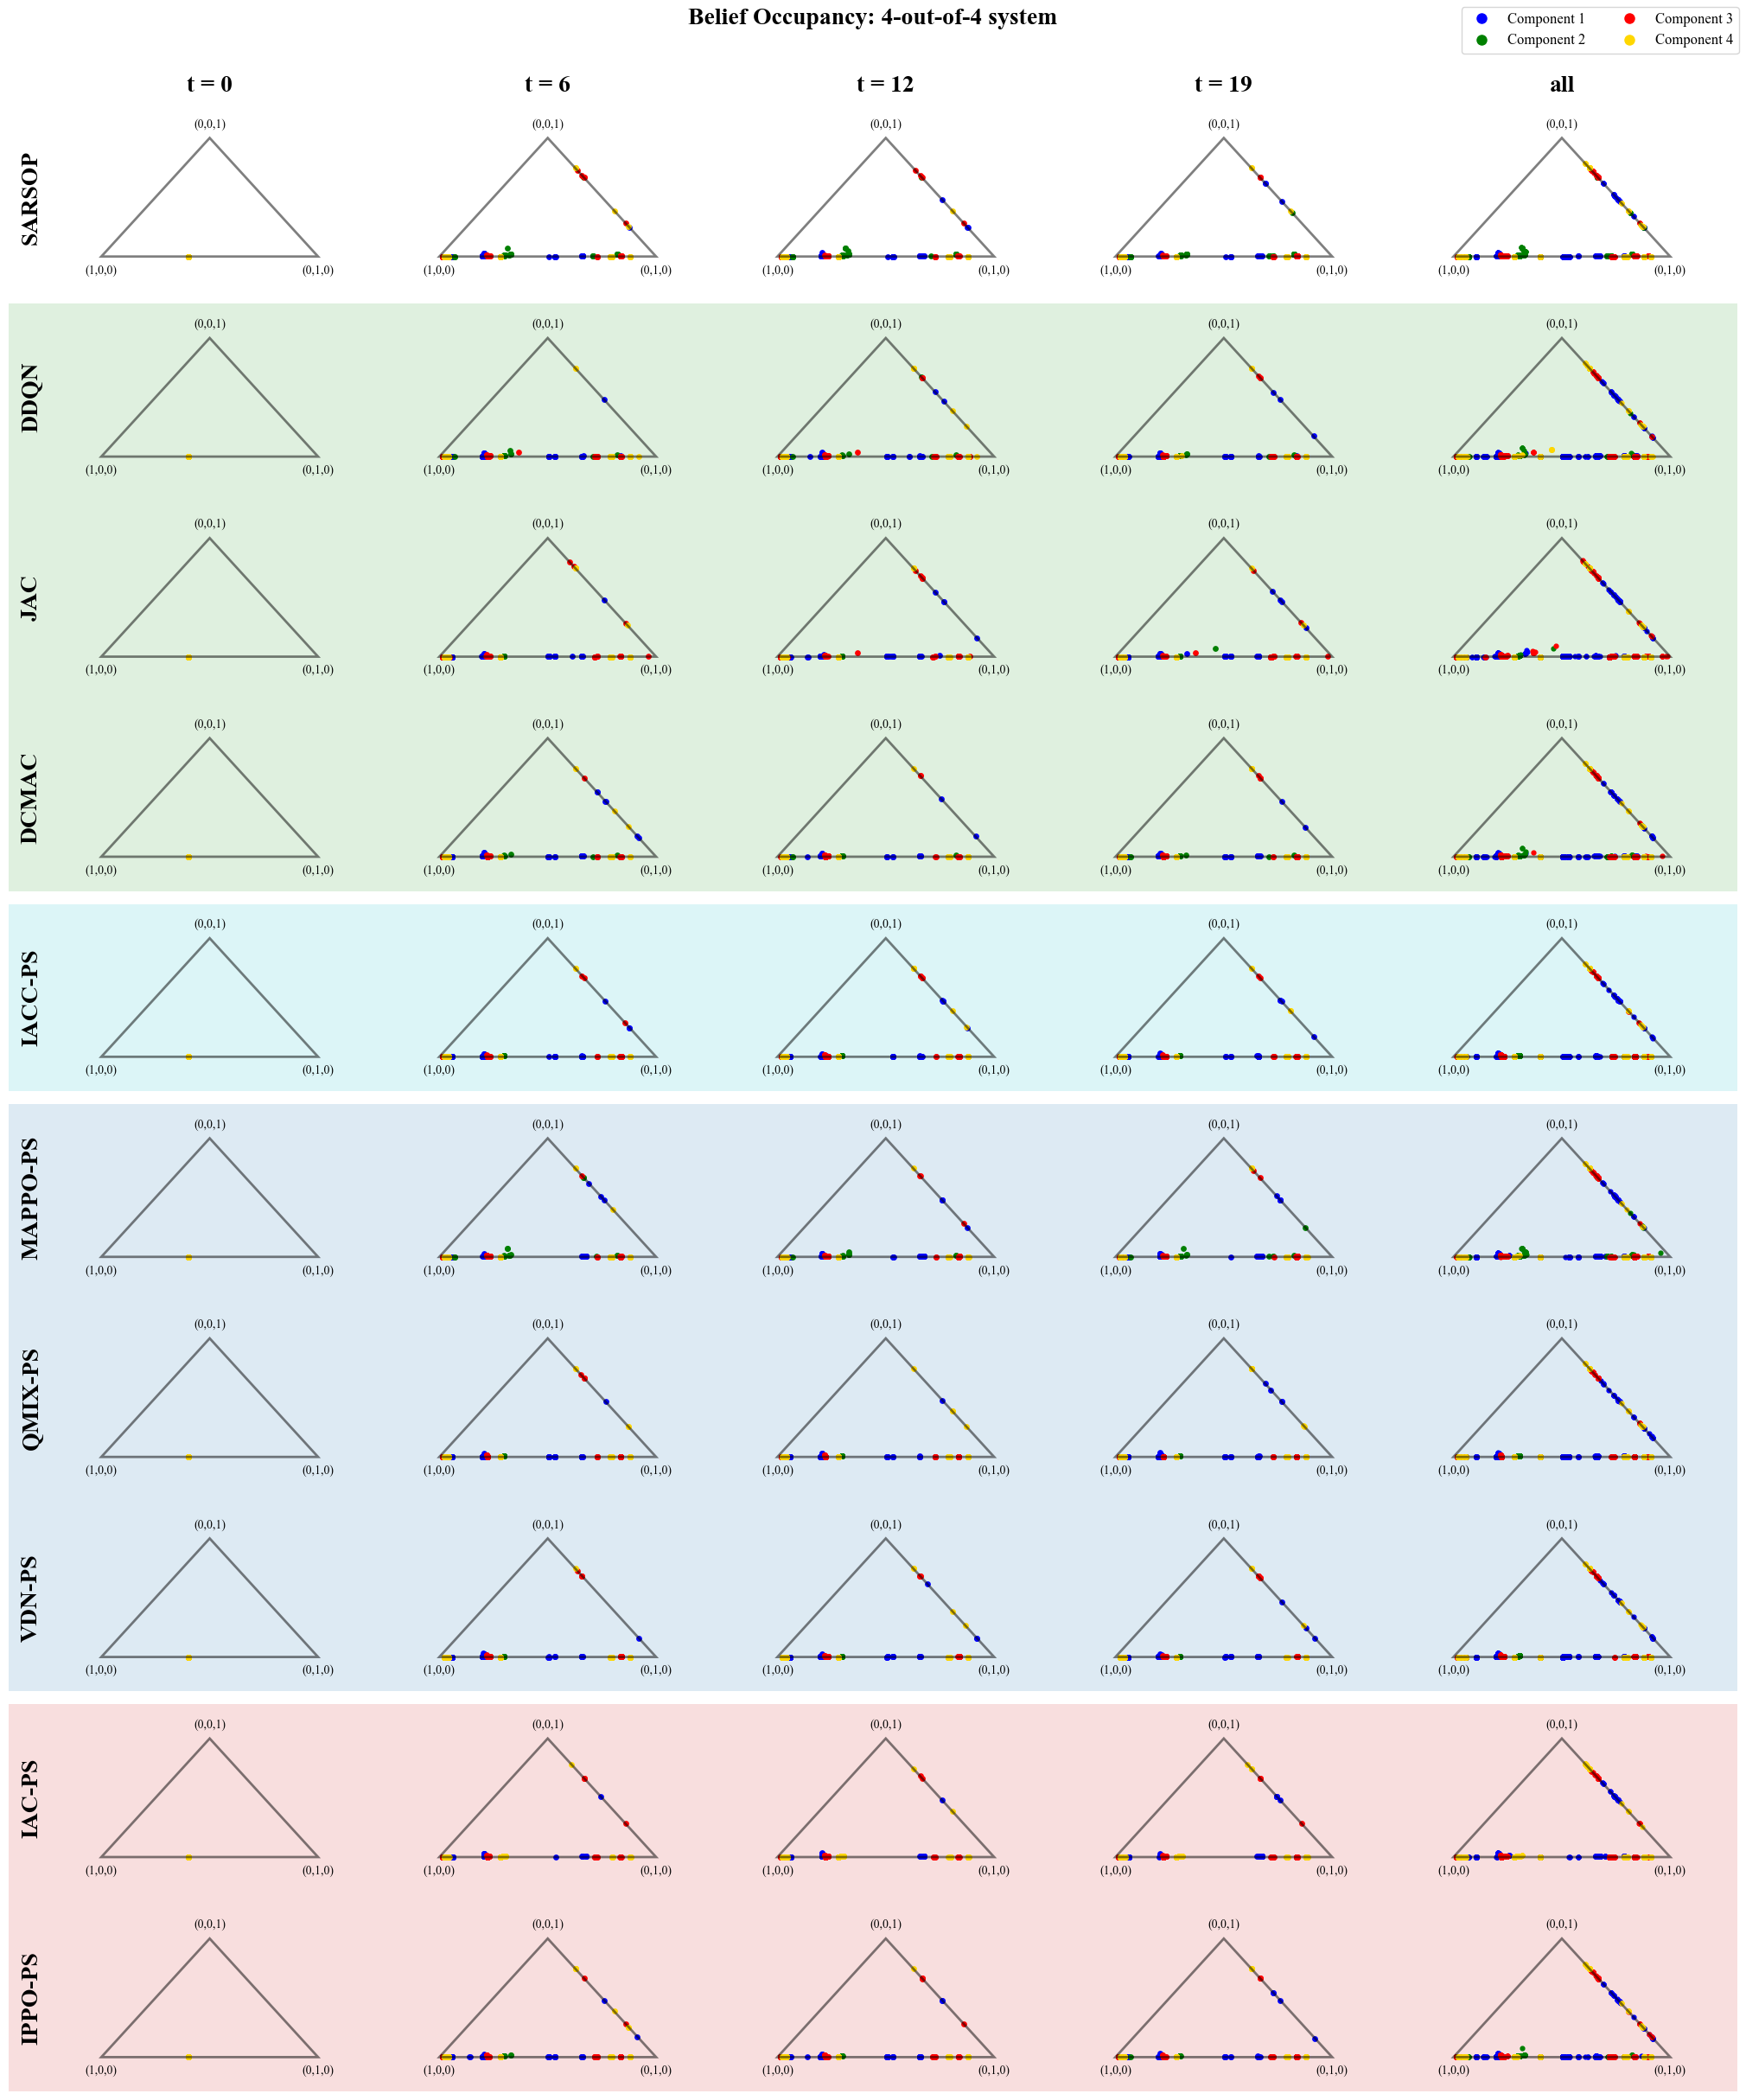

In [8]:
for env_setting in SETTINGS:
    plot_belief_space(env_setting, save_fig=False)